In [4]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [5]:
# Load train and test datasets

train_df = pd.read_csv(
    r"C:\hireai-ml\data\processed\train.csv"
)

test_df = pd.read_csv(
    r"C:\hireai-ml\data\processed\test.csv"
)

# Train data info
print(train_df.shape)

print(train_df.head())

print(train_df.isnull().sum())

# Fill missing values in train data
train_df.fillna(
    "Unknown",
    inplace=True
)
# Fill missing values in test data
test_df.fillna(
    "Unknown",
    inplace=True
)


(79840, 22)
   application_id  candidate_id  job_id application_date       status  \
0           66735         30433       7       2026-03-11      applied   
1           64779         29450      10       2025-08-03  interviewed   
2           17695          5854       8       2025-09-27  shortlisted   
3           45409         19740       7       2025-08-16  shortlisted   
4           40653         17363       7       2025-09-12      applied   

               name                              email  \
0          pooja li              pooja.li5775@zoho.com   
1      meera pillai           meera.pillai834@mail.com   
2  ayesha kobayashi    ayesha.kobayashi53937@gmail.com   
3     liam martinez  liam.martinez26447@rediffmail.com   
4   priya mukherjee   priya.mukherjee18184@outlook.com   

                                              skills  experience_years  \
0           django|flask|mysql|python|rabbitmq|redis                 8   
1                      jira|pytorch|spark|tensorflow

In [6]:
# Features and target from train data

X_train = train_df["required_skills"]

y_train = train_df["role"]

# Features and target from test data

X_test = test_df["required_skills"]

y_test = test_df["role"]

# Shapes
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(79840,)
(19960,)
(79840,)
(19960,)


In [8]:
model = Pipeline([

    ('tfidf', TfidfVectorizer()),

    ('classifier', MultinomialNB())
])

# Train model
model.fit(
    X_train,
    y_train
)

model


,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [10]:
y_pred = model.predict(X_test)
print(y_pred[:5])

['machine learning engineer' 'data engineer' 'mobile developer'
 'devops engineer' 'mobile developer']


In [11]:
import sys
import os

sys.path.append(r"C:\hireai-ml")

In [12]:
from src.eval.metrics import classification_metrics

results = classification_metrics(
    y_test,
    y_pred
)

print(results)

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'confusion_matrix': array([[1937,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0, 2007,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0, 2031,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0, 2042,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0, 1898,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0, 2033,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0, 1990,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0, 2000,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0, 1976,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0, 2046]])}


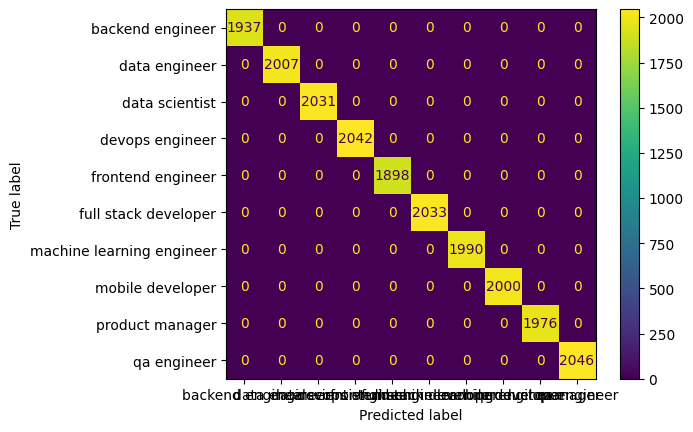

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [14]:
from src.eval.error_analysis import (
    classification_error_analysis
)

errors = classification_error_analysis(
    y_test,
    y_pred
)

print(errors.head())

Empty DataFrame
Columns: [actual, predicted]
Index: []


In [54]:
from src.eval.error_analysis import classification_error_analysis

errors = classification_error_analysis(
    y_test,
    y_pred
)

print(errors)

Empty DataFrame
Columns: [actual, predicted]
Index: []


In [46]:
import shap

In [48]:
classifier = model.named_steps['classifier']

print(classifier)

MultinomialNB()


In [49]:
vectorizer = model.named_steps['tfidf']

feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['agile' 'airflow' 'analytics' 'android' 'ansible' 'api' 'aws' 'cd' 'ci'
 'css' 'dart' 'dbt' 'django' 'docker' 'express' 'firebase' 'flutter' 'git'
 'hadoop' 'html']


In [50]:
import numpy as np

top_features = np.argsort(
    classifier.feature_log_prob_[0]
)[-20:]

print(feature_names[top_features])

['postman' 'pytest' 'react' 'pytorch' 'selenium' 'scikit' 'redux'
 'roadmapping' 'swift' 'stakeholder' 'sql' 'spark' 'webpack' 'python'
 'docker' 'postgresql' 'rest' 'api' 'django' 'redis']


# Explainability Findings

Important skill keywords influencing predictions were extracted from the TF-IDF + MultinomialNB pipeline.

This serves as initial explainability analysis for the current text-classification workflow.